<a href="https://colab.research.google.com/github/July230/AviDetect/blob/develop/Avance1_Generacion_seleccion_preprocesado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avance 1: Generación o selección del set de datos  y preprocesado (retro)

## Ian Julián Estrada Castro - A01352823

Usaremos el dataset [Drone vs Bird:Aerial Object Classification Dataset](https://www.kaggle.com/datasets/muhammadsaoodsarwar/drone-vs-bird) disponible públicamente [Kaggle](https://www.kaggle.com) bajo la licencia **Apache 2.0**.

Podemos importar el dataset vía kagglehub.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhammadsaoodsarwar/drone-vs-bird")

print("Path to dataset files:", path)

100%|██████████| 1.59G/1.59G [01:32<00:00, 18.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/muhammadsaoodsarwar/drone-vs-bird/versions/1


## Librerías

In [28]:
!pip install split-folders

In [29]:
import os
import shutil
import random
import splitfolders
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


El dataset tiene dos carpetas con 4106 imágenes en total:
* bird: 1607 imágenes
* drone: 2499 imágenes

Sin embargo, está desbalanceado al contar con más imágenes de drones que de aves. Adicionalmente, es necesario hacer el split inicial para obtener train y test. Posteriormente, dividir train en train y validation. Las divisiones comunes para esta división son 70/15/15 u 80/10/10.
Haremos una división de 70% train, 15% validation y 15% test.

In [24]:
def cleanDir(dir, directoriesToClean):
  """
  Clean the directories in the output directory

  Parameters
  ----------
  dir : str
    Path to the directory you want to clean
  directoriesToClean : list
    List of the directories to clean

  Returns
  -------
  None
  """
  for directory in directoriesToClean:
      directoryPath = os.path.join(outputDir, directory)

      if os.path.exists(directoryPath):
          shutil.rmtree(directoryPath)
          print(f"Deleted: {directoryPath}")

NOTA: Se consultó a gemini para generar el script del split

El nombre del dataset donde haremos el split es BirdVSDrone

In [30]:
datasetDir = os.path.join(path, "dataset")
outputDir = "/content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone"

In [26]:
# directoriesToClean = ["train", "test"]
# cleanDir(outputDir, directoriesToClean)

Deleted: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/train
Created empty folder: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/train
Deleted: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/test
Created empty folder: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/test


In [31]:
!ls {datasetDir}

bird  drone


La librería splitfolders nos permite hacer el split de manera sencilla

In [32]:
splitfolders.ratio(datasetDir, output=outputDir, seed=42, ratio=(0.7, 0.15, 0.15))

Copying files: 4106 files [01:14, 54.77 files/s]


Dato curioso: La semilla 42 se usa como tradición de programadores y científicos de datos. Aparece de la novela de ciencia ficción de Douglas Adams: *La guía del autoestopista galáctico (1979)*. Aquí, la supercomputadora llamada *Deep though* revela que la respuesta a la gran pregunta de "la vida, el universo y todo lo demás" es 42. Realmente no tiene alguna ventaja computacional.

Verificamos que existan las imagenes

In [39]:
def countImages(dir):
  """
  Count the number of images in a directory

  Parameters
  ----------
  dir : str
    Path to the directory where the images are

  Returns
  -------
  None
  """
  for directory in ["train", "test", "val"]:
    print(f"Images in {directory}:")
    for subdirectory in ["bird", "drone"]:
      print(f"\t{subdirectory}: {len(os.listdir(os.path.join(outputDir, directory, subdirectory)))}")

In [40]:
countImages(outputDir)

Images in train:
	bird: 1124
	drone: 1749
Images in test:
	bird: 242
	drone: 376
Images in val:
	bird: 241
	drone: 374


Visualizamos las imagenes que hay

In [41]:
trainDir = os.path.join(outputDir, "train")
testDir = os.path.join(outputDir, "test")
valDir = os.path.join(outputDir, "val")

In [42]:
def getImages(dir, numImages, seed=42):
  """
  Get the images from a directory and show them

  Parameters
  ----------
  dir : str
    Path to the directory that contains the train set
  numImages : int
    Images to show

  Returns
  -------
  None
  """

  random.seed(seed)

  plt.figure(figsize=(10,10))
  images = [i for i in os.listdir(dir) if os.path.isfile(os.path.join(dir, i))]
  random.shuffle(images)
  images = images[:numImages]

  for i, image in enumerate(images):
    img = plt.imread(os.path.join(dir, image))
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(img, cmap=plt.cm.binary)

  plt.show()

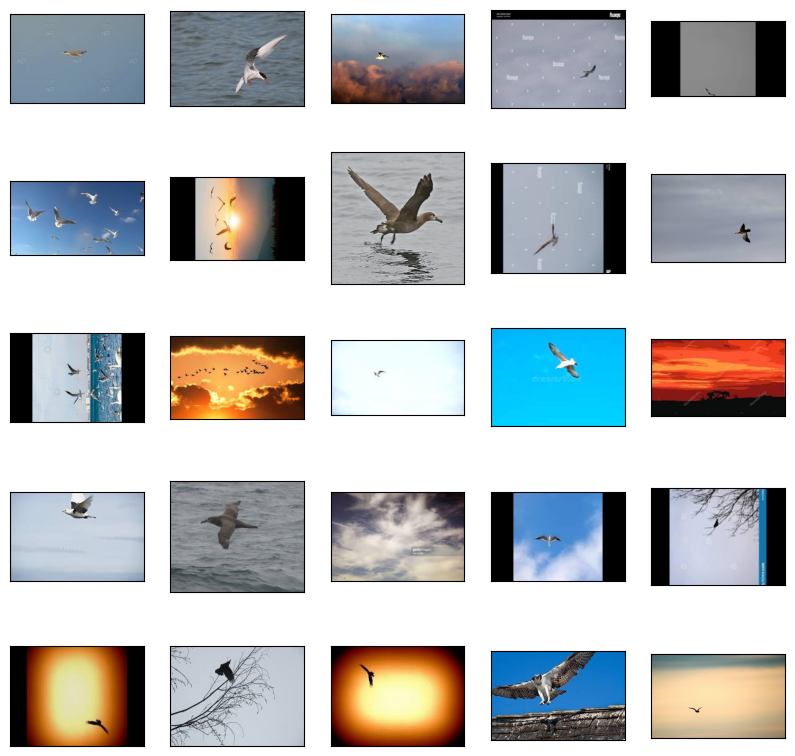

In [46]:
getImages(os.path.join(trainDir, "bird"), 25)

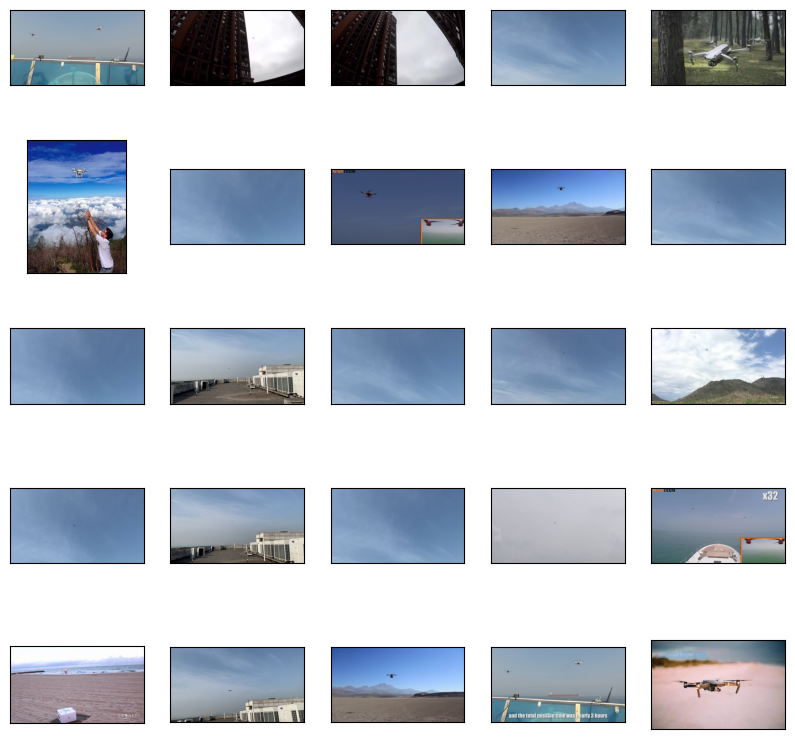

In [47]:
getImages(os.path.join(trainDir, "drone"), 25)

## Data augmentation
Usamos ImageDataGenerator para generar imagenes nuevas en el ram mientras entrenamos para no desperdiciar espacio.

In [48]:
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [50]:
trainDatagen = ImageDataGenerator(
							rescale = 1./255, # Mandatory
						  rotation_range = 10,
						  width_shift_range = 0.2,
					  # height_shift_range = 0.2,
						#	shear_range = 0.3,
						  zoom_range = 0.3,
						  horizontal_flip = True
       )

Found 2871 images belonging to 2 classes.


<Figure size 640x480 with 0 Axes>

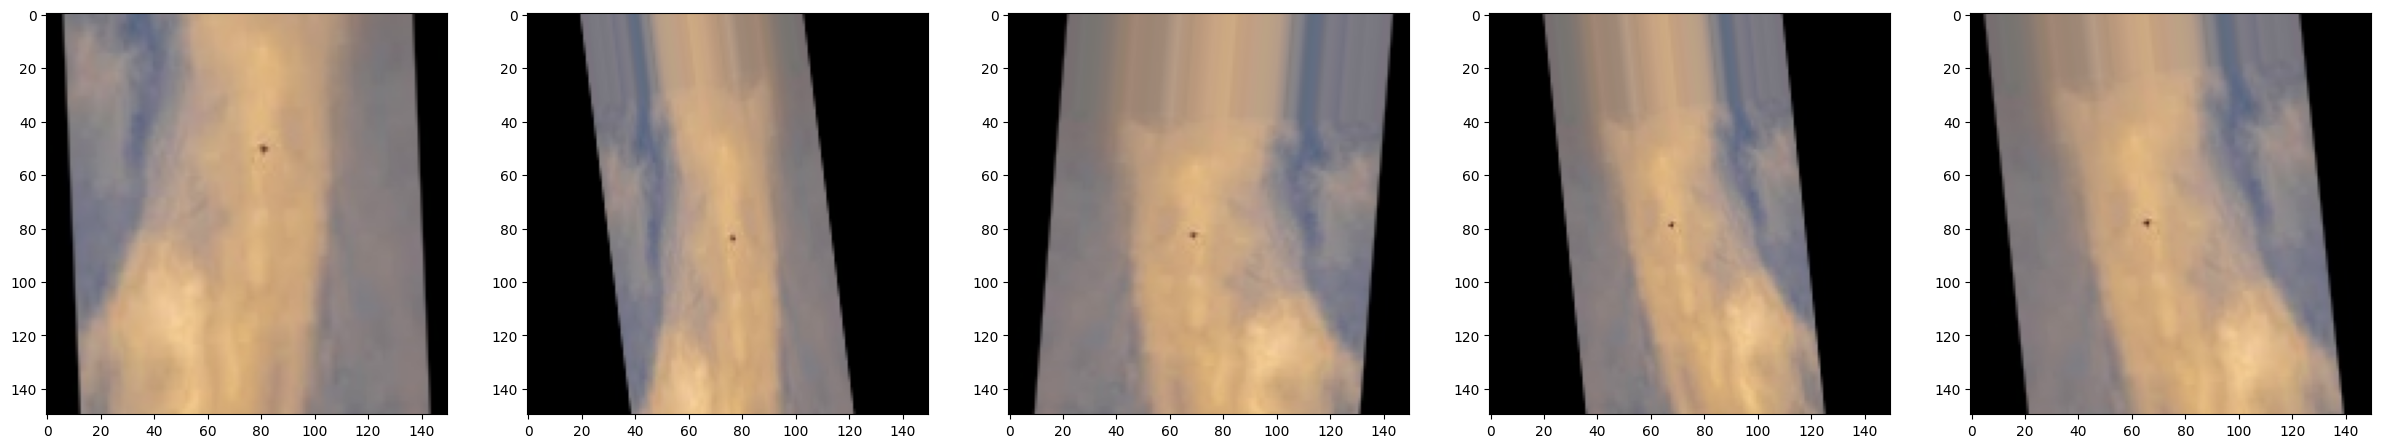

In [51]:
trainGenerator = trainDatagen.flow_from_directory(
							trainDir,
							target_size = (150, 150),
							batch_size = 1, # Num of images that takes from the directory
							class_mode ='binary', # Aqui tiene que coincidr con lo que vaya en la ultima neurona de la red neuronal
							)


plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, 5, figsize=(30, 8))

for i in range(5) :
  axarr[i].imshow(trainGenerator[0][0][0])

## Red neuronal convolutiva

In [52]:
model = models.Sequential()
model.add(layers.Conv2D(10, (3, 3), activation="relu", input_shape = (150,150,3)))
model.add(layers.Flatten())
model.add(layers.Dense(256,activation="relu"))
model.add(layers.Dense(1,activation="sigmoid")) # Binary on the last neuron for 0 or 1

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 148, 148, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 219040)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    56,074,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,075,033 (213.91 MB)

 Trainable params: 56,075,033 (213.91 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.compile(loss="binary_crossentropy",
						optimizer=optimizers.RMSprop(learning_rate=2e-5),
						metrics=["acc"])

Epoch 1/4
2871/2871 ━━━━━━━━━━━━━━━━━━━━ 118s 40ms/step - acc: 0.7046 - loss: 0.6147
Epoch 2/4
2871/2871 ━━━━━━━━━━━━━━━━━━━━ 96s 33ms/step - acc: 0.7489 - loss: 0.5441
Epoch 3/4
2871/2871 ━━━━━━━━━━━━━━━━━━━━ 91s 32ms/step - acc: 0.7503 - loss: 0.5328
Epoch 4/4
2871/2871 ━━━━━━━━━━━━━━━━━━━━ 91s 32ms/step - acc: 0.7611 - loss: 0.5317


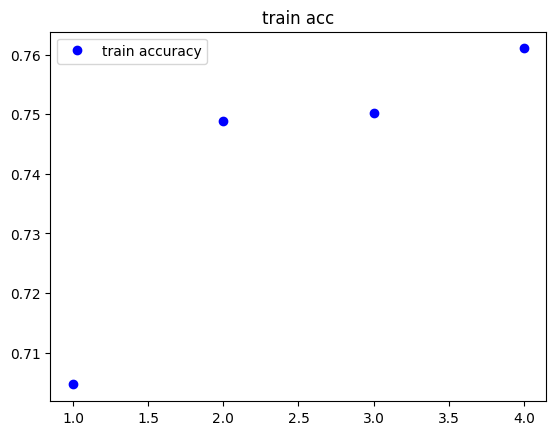

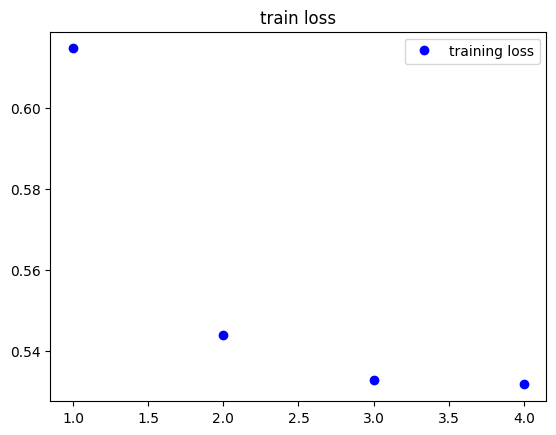

In [54]:
history = model.fit(trainGenerator, epochs = 4)

acc = history.history["acc"]
loss = history.history["loss"]

epochs = range(1, len(acc)+1)

plt.plot(epochs,acc, "bo", label="train accuracy")
plt.title('train acc')
plt.legend()

plt.figure()

plt.plot(epochs,loss, "bo", label ="training loss")
plt.title("train loss")
plt.legend()

plt.show()

In [55]:
valDatagen = ImageDataGenerator(1./255)
valGenerator = valDatagen.flow_from_directory(
    valDir,
    target_size = (150, 150),
    batch_size = 20,
    class_mode = "binary")

valLoss, valAcc = model.evaluate(valGenerator, steps = 25)
print("\nval acc :\n", valAcc)

Found 615 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 406ms/step - acc: 0.7520 - loss: 103.7731

val acc :
 0.7519999742507935


Con test sólo queremos lo real, por eso aqui siempre sólo se escala

In [56]:
testDatagen = ImageDataGenerator(1./255)
testGenerator = testDatagen.flow_from_directory(
					testDir,
					target_size = (150, 150),
					batch_size = 20,
					class_mode= 'binary')

testLoss, testAcc = model.evaluate(testGenerator, steps = 25)
print('\ntest acc :\n', testAcc)

Found 618 images belonging to 2 classes.
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 370ms/step - acc: 0.7800 - loss: 99.5664

test acc :
 0.7799999713897705
